# Customer Cancellation Risk Model

Binary classification: predict the probability that a booking will be cancelled.

The model uses customer history, ratings, peak-time behavior, and pricing sensitivity. Post-booking fields are excluded to avoid target leakage.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [5]:
DATA_DIR_CANDIDATES = [
    Path.cwd() / 'src' / 'DataCSVFiles',
    Path.cwd() / 'DataCSVFiles',
    Path.cwd().parents[1] / 'DataCSVFiles',
]
DATA_DIR = next(
    (path for path in DATA_DIR_CANDIDATES if (path / 'bookings.csv').exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError('Could not locate src/DataCSVFiles/bookings.csv')


df_booking = pd.read_csv(DATA_DIR / 'bookings.csv')
df_customer = pd.read_csv(DATA_DIR / 'customers.csv')

print('Data directory:', DATA_DIR)
print('Bookings:', df_booking.shape)
print('Customers:', df_customer.shape)
display(df_booking.head())
display(df_customer.head())

Data directory: c:\Users\KITTU-PALKIN\OneDrive\Documents\Rupahli\GUVI\Projects\Rapido\src\DataCSVFiles
Bookings: (100000, 22)
Customers: (10000, 13)


,booking_id,booking_date,booking_time,day_of_week,is_weekend,hour_of_day,city,pickup_location,drop_location,vehicle_type,...,actual_ride_time_min,traffic_level,weather_condition,base_fare,surge_multiplier,booking_value,booking_status,incomplete_ride_reason,customer_id,driver_id
0,B_000001,2025-12-11,00:07:00,Thursday,0,0,Mumbai,Loc_19,Loc_16,Bike,...,NaN,High,Heavy Rain,76.12,2.0,148.22,Cancelled,NaN,C_005097,D_004592
1,B_000002,2025-07-07,06:13:00,Monday,0,6,Mumbai,Loc_32,Loc_38,Cab,...,42.28,Medium,Heavy Rain,254.15,1.8,465.85,Completed,NaN,C_008459,D_000148
2,B_000003,2025-08-23,08:53:00,Saturday,1,8,Chennai,Loc_28,Loc_1,Auto,...,NaN,Low,Heavy Rain,234.20,1.9,457.03,Cancelled,NaN,C_003471,D_004976
3,B_000004,2025-04-12,10:25:00,Saturday,1,10,Delhi,Loc_16,Loc_30,Bike,...,4.76,Medium,Rain,28.20,1.8,51.03,Completed,NaN,C_002161,D_001173
4,B_000005,2025-08-23,00:08:00,Saturday,1,0,Hyderabad,Loc_22,Loc_31,Bike,...,64.53,Medium,Clear,118.77,1.2,144.73,Completed,NaN,C_005617,D_001175


,customer_id,customer_gender,customer_age,customer_city,customer_signup_days_ago,preferred_vehicle_type,total_bookings,completed_rides,cancelled_rides,incomplete_rides,cancellation_rate,avg_customer_rating,customer_cancel_flag
0,C_000001,Non-Binary,56,Bangalore,556,Cab,10,9,1,0,0.100000,3.8,0
1,C_000002,Male,46,Bangalore,82,Bike,8,7,1,0,0.125000,4.1,0
2,C_000003,Female,32,Delhi,969,Bike,7,4,1,2,0.142857,3.8,0
3,C_000004,Female,60,Hyderabad,549,Bike,11,7,3,1,0.272727,3.7,1
4,C_000005,Non-Binary,25,Hyderabad,359,Bike,9,5,3,1,0.333333,3.8,1


## Target and leakage policy

`Cancelled` is the positive class. `Completed` and `Incomplete` are treated as not cancelled. Fields created after the booking outcome, such as actual ride duration and incomplete-ride reason, are excluded. Customer history columns are retained only if they were calculated before the current booking.

In [6]:
df = df_booking.merge(
    df_customer,
    on='customer_id',
    how='left',
    validate='many_to_one',
    suffixes=('', '_customer')
)

df['cancelled_target'] = (df['booking_status'] == 'Cancelled').astype(int)

print(df['booking_status'].value_counts())
print('Cancellation rate:', df['cancelled_target'].mean())
print('Missing values in target:', df['cancelled_target'].isna().sum())

booking_status
Completed     68346
Cancelled     23284
Incomplete     8370
Name: count, dtype: int64
Cancellation rate: 0.23284
Missing values in target: 0


In [7]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['booking_time'] = pd.to_datetime(df['booking_time'])

df['booking_month'] = df['booking_date'].dt.month
df['booking_hour'] = df['booking_time'].dt.hour

# Peak-time behavior known at booking time.
df['is_peak_time'] = df['booking_hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)

# Pricing sensitivity proxies known at booking time.
df['fare_per_km'] = df['booking_value'] / df['ride_distance_km'].clip(lower=0.01)
df['fare_markup'] = df['booking_value'] / df['base_fare'].clip(lower=0.01)
df['surge_cost'] = df['surge_multiplier'] - 1.0

df[['booking_value', 'base_fare', 'fare_per_km', 'fare_markup', 'surge_cost']].describe()

C:\Users\KITTU-PALKIN\AppData\Local\Temp\ipykernel_38872\110133221.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['booking_time'] = pd.to_datetime(df['booking_time'])


,booking_value,base_fare,fare_per_km,fare_markup,surge_cost
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,336.344779,211.678063,30.021978,1.588847,0.588973
std,208.017661,120.908740,18.475238,0.328454,0.325193
min,27.280000,28.020000,8.382117,0.950019,0.000000
25%,179.210000,118.627500,17.631785,1.339191,0.300000
50%,290.090000,187.345000,25.546158,1.582583,0.600000
75%,448.470000,287.462500,37.146743,1.822975,0.800000
max,1265.590000,529.960000,210.790000,2.414902,1.300000


In [8]:
# These fields are unavailable or unsafe when predicting at booking time.
post_booking_fields = [
    'booking_status',
    'cancelled_target',
    'actual_ride_time_min',
    'incomplete_ride_reason',
    'booking_id',
    'customer_id',
    'driver_id',
    'booking_date',
    'booking_time',
    'pickup_location',
    'drop_location',
    'customer_city',
    'customer_age',
]

# These customer-history fields are historical snapshots from before the current booking.
history_fields = [
    'total_bookings',
    'completed_rides',
    'cancelled_rides',
    'incomplete_rides',
    'cancellation_rate',
    'avg_customer_rating',
    'customer_cancel_flag',
]

feature_columns = [
    column for column in df.columns
    if column not in post_booking_fields
]

missing_history_fields = [
    column for column in history_fields
    if column not in feature_columns
]
if missing_history_fields:
    raise ValueError(f'Expected historical features are missing: {missing_history_fields}')

X = df[feature_columns].copy()
y = df['cancelled_target'].copy()

print('Historical customer features retained:', history_fields)
print('Features:', X.shape[1])
print('Target counts:\n', y.value_counts())

Historical customer features retained: ['total_bookings', 'completed_rides', 'cancelled_rides', 'incomplete_rides', 'cancellation_rate', 'avg_customer_rating', 'customer_cancel_flag']
Features: 28
Target counts:
 cancelled_target
0    76716
1    23284
Name: count, dtype: int64


In [9]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [10]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    ),
}

results = {}
for model_name, estimator in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    results[model_name] = {
        'pipeline': pipeline,
        'probabilities': probabilities,
        'predictions': predictions,
        'roc_auc': roc_auc_score(y_test, probabilities),
        'average_precision': average_precision_score(y_test, probabilities),
    }
    print(model_name)
    print('ROC-AUC:', results[model_name]['roc_auc'])
    print('Average precision:', results[model_name]['average_precision'])
    print(classification_report(y_test, predictions, zero_division=0))

Logistic Regression
ROC-AUC: 0.7791270017133516
Average precision: 0.49629090639935725
              precision    recall  f1-score   support

           0       0.89      0.70      0.78     15343
           1       0.42      0.72      0.53      4657

    accuracy                           0.70     20000
   macro avg       0.65      0.71      0.66     20000
weighted avg       0.78      0.70      0.72     20000

Random Forest
ROC-AUC: 0.7860262428593847
Average precision: 0.4981259109560559
              precision    recall  f1-score   support

           0       0.88      0.74      0.80     15343
           1       0.44      0.68      0.53      4657

    accuracy                           0.72     20000
   macro avg       0.66      0.71      0.67     20000
weighted avg       0.78      0.72      0.74     20000



Selected model: Random Forest
Confusion matrix at threshold 0.5:
[[11331  4012]
 [ 1496  3161]]


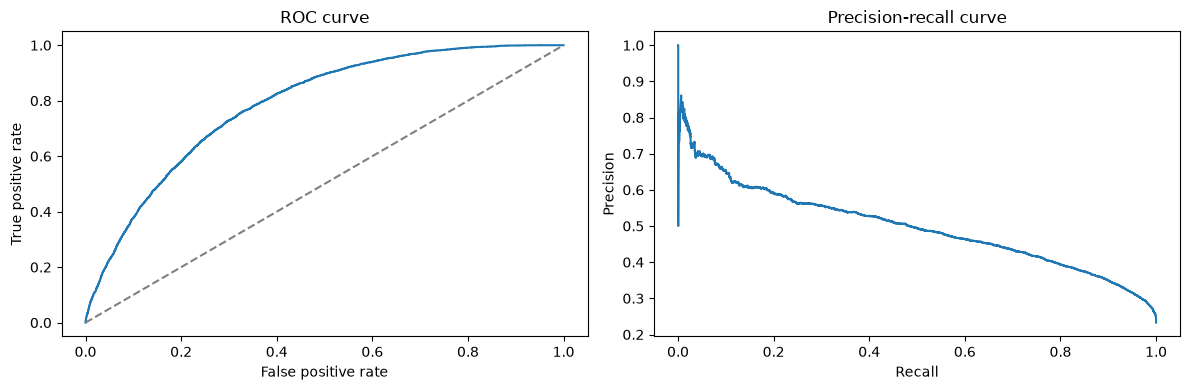

In [11]:
selected_model_name = max(
    results,
    key=lambda name: results[name]['average_precision'],
)
selected = results[selected_model_name]
selected_probabilities = selected['probabilities']

print('Selected model:', selected_model_name)
print('Confusion matrix at threshold 0.5:')
print(confusion_matrix(y_test, selected['predictions']))

false_positive_rate, true_positive_rate, _ = roc_curve(y_test, selected_probabilities)
precision, recall, thresholds = precision_recall_curve(y_test, selected_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(false_positive_rate, true_positive_rate)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC curve')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')

axes[1].plot(recall, precision)
axes[1].set_title('Precision-recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
plt.tight_layout()
plt.show()

In [12]:
# Choose a threshold based on the business cost of missed cancellations.
threshold_rows = []
for threshold in np.arange(0.20, 0.81, 0.05):
    threshold_predictions = (selected_probabilities >= threshold).astype(int)
    report = classification_report(
        y_test,
        threshold_predictions,
        output_dict=True,
        zero_division=0,
    )
    threshold_rows.append({
        'threshold': round(float(threshold), 2),
        'cancellation_precision': report['1']['precision'],
        'cancellation_recall': report['1']['recall'],
        'cancellation_f1': report['1']['f1-score'],
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results)

chosen_threshold = 0.50
final_predictions = (selected_probabilities >= chosen_threshold).astype(int)
print(classification_report(y_test, final_predictions, zero_division=0))

,threshold,cancellation_precision,cancellation_recall,cancellation_f1
0,0.20,0.315936,0.950183,0.474200
1,0.25,0.335021,0.923341,0.491653
2,0.30,0.352279,0.894353,0.505461
3,0.35,0.371599,0.856345,0.518292
4,0.40,0.392272,0.802233,0.526902
5,0.45,0.417634,0.741464,0.534313
6,0.50,0.440680,0.678763,0.534404
7,0.55,0.462496,0.606399,0.524761
8,0.60,0.485563,0.530814,0.507181
9,0.65,0.512960,0.446210,0.477262


              precision    recall  f1-score   support

           0       0.88      0.74      0.80     15343
           1       0.44      0.68      0.53      4657

    accuracy                           0.72     20000
   macro avg       0.66      0.71      0.67     20000
weighted avg       0.78      0.72      0.74     20000



In [13]:
def predict_cancellation_probability(new_bookings: pd.DataFrame) -> pd.DataFrame:
    """Return cancellation probability and a thresholded risk label."""
    missing_columns = set(feature_columns) - set(new_bookings.columns)
    if missing_columns:
        raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

    probabilities = selected['pipeline'].predict_proba(new_bookings[feature_columns])[:, 1]
    return pd.DataFrame({
        'cancellation_probability': probabilities,
        'high_risk': probabilities >= chosen_threshold,
    }, index=new_bookings.index)

# Example: score the first five test rows.
display(predict_cancellation_probability(X_test.head()))

,cancellation_probability,high_risk
70161,0.334641,False
94202,0.671805,True
32608,0.529604,True
8990,0.273212,False
1996,0.609139,True
